In [1]:
import pandas as pd
import pathlib
import matplotlib.pyplot as plt
%matplotlib inline
import sys
import numpy as np
import seaborn as sns

## Distribuição de porosidade

In [2]:
wells_porosity_path = pathlib.Path("../../../../data/ANP/processed/area1/area_1_porsty.npy")
por_np = np.load(wells_porosity_path)

In [3]:
por_np[0]

array([55.        , 30.        ,  0.        , 26.68351648])

In [4]:
por_df = pd.DataFrame(data=por_np)
por_df.columns = ["x", "y", "z", "porosity"]
test_well_coord = (33, 184)
por_df["train"] = por_df.apply(
    lambda row: 0 if row["x"] == test_well_coord[0] and row["y"] == test_well_coord[1] else 1, axis=1) 
por_df.head()

,x,y,z,porosity,train
0,55.0,30.0,0.0,26.683516,1
1,55.0,30.0,1.0,21.352747,1
2,55.0,30.0,2.0,20.974725,1
3,55.0,30.0,3.0,25.047253,1
4,55.0,30.0,4.0,20.696703,1


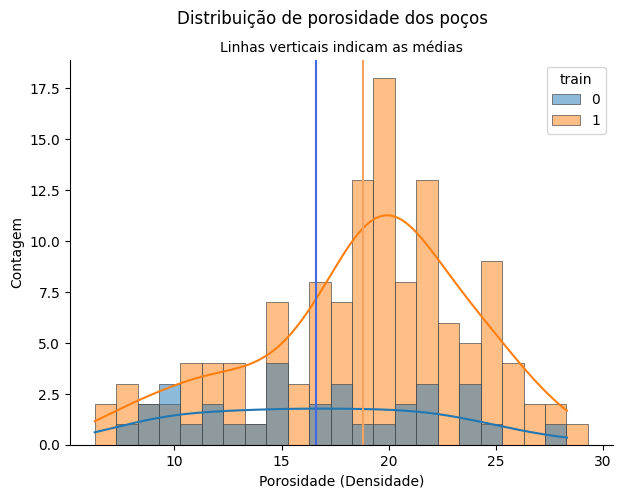

In [5]:
f, ax = plt.subplots(figsize=(7, 5))

mean_train = por_df[por_df['train'] == 1]['porosity'].mean()
mean_test = por_df[por_df['train'] == 0]['porosity'].mean()

# sns.set_theme(style="ticks")
sns.despine(f)
sns.histplot(
    por_df,
    x="porosity", hue="train",
    # palette="light:m_r",
    edgecolor=".3",
    linewidth=.5,
    binwidth=1, kde=True
    
)

plt.axvline(mean_train, color="sandybrown")
plt.axvline(mean_test, color="royalblue")
plt.suptitle("Distribuição de porosidade dos poços")
plt.title("Linhas verticais indicam as médias", fontsize=10)
plt.xlabel("Porosidade (Densidade)")
plt.ylabel("Contagem")
plt.savefig("wells_porosity_dist.png")
plt.show()

In [6]:
std_total = por_df['porosity'].std()
mean_total = por_df['porosity'].mean()
mean_total, std_total 

(18.368652374411294, 5.125344586260757)

Text(0.5, 0.98, 'Distribuição de porosidade dos poços')

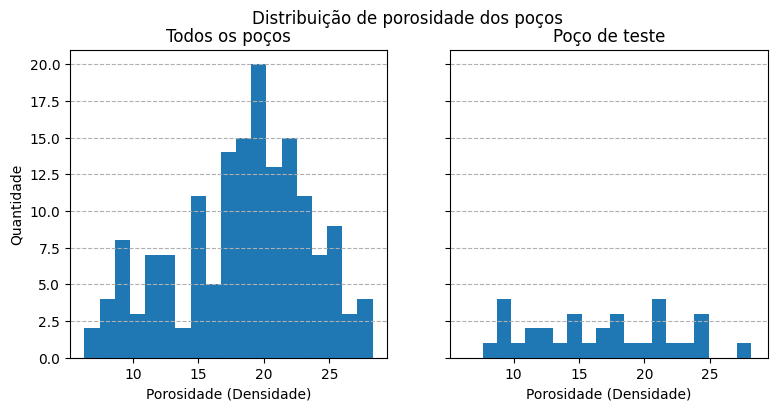

In [7]:
bins = 19
fig, axs = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(9, 4), sharex=True)
axs[0].hist(por_np[:,3], bins=bins)
axs[0].set_title("Todos os poços")
axs[0].set_xlabel("Porosidade (Densidade)")
axs[0].set_ylabel("Quantidade")
# axs[0].set_ylim((1, 20))
axs[0].grid(axis='y', linestyle="--")

test_well_coord = (33, 184)
target_data =  por_np[por_np[:, 0] == test_well_coord[0]]
target_data =  target_data[target_data[:, 1] == test_well_coord[1]]
axs[1].hist(target_data[:,3], bins=bins)
axs[1].set_title("Poço de teste")
# axs[1].set_ylabel("Porosidade (Densidade)")
# axs[1].set_ylim((1, 20))
axs[1].set_xlabel("Porosidade (Densidade)")
axs[1].grid(axis='y', linestyle="--")

plt.suptitle("Distribuição de porosidade dos poços")

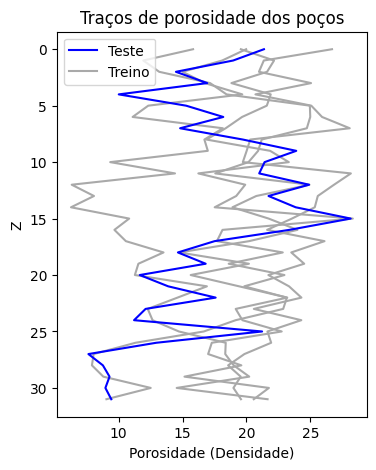

In [8]:
unique_coords = np.unique(por_df[["x", "y"]].values, axis=0)
plt.figure(figsize=(4, 5))
was_train = False
test_color = "blue"
for coord in unique_coords:
    target_data = por_df[np.all((por_df[["x", "y"]] == coord).values, axis=1)]
    if tuple(coord) == test_well_coord:
        color = test_color
    else:
        color="darkgrey"
        
    if color==test_color:
        plt.plot(target_data["porosity"], target_data["z"], color=color, label="Teste", zorder=10)
    elif not was_train:
        plt.plot(target_data["porosity"], target_data["z"], color=color, label="Treino")
        was_train = True
    else:
        plt.plot(target_data["porosity"], target_data["z"], color=color)
ax = plt.gca()
ax.invert_yaxis()
plt.legend()
plt.xlabel("Porosidade (Densidade)")
plt.ylabel("Z")
plt.title("Traços de porosidade dos poços")
plt.savefig("porosity_traces.png")
plt.show()

## Resultados dos experimentos

In [9]:
exp_utils_path = pathlib.Path("../../../../src/exploration/exp_utils")
sys.path.insert(0, str(exp_utils_path.resolve()))
from explorationUtils import ExplorationCube

In [10]:
folders = pathlib.Path(".").glob("*")
folders = [el for el in folders if el.is_dir() and str(el)[0] != "."]
folders

[PosixPath('max-p_10000_n-layers_15'),
 PosixPath('max-p_200_n-layers_5'),
 PosixPath('max-p_-1_n-layers_1'),
 PosixPath('max-p_100_n-layers_1'),
 PosixPath('max-p_10000_n-layers_5-beta'),
 PosixPath('max-p_100_n-layers_-1'),
 PosixPath('max-p_10000_n-layers_5'),
 PosixPath('max-p_10000_n-layers_15-lgbm-min-data_5'),
 PosixPath('max-p_-1_n-layers_5_preds_3'),
 PosixPath('max-p_100_n-layers_5'),
 PosixPath('max-p_-1_n-layers_-1'),
 PosixPath('max-p_400_n-layers_5'),
 PosixPath('max-p_200_n-layers_-1'),
 PosixPath('max-p_100_n-layers_1-window-1-feats-3'),
 PosixPath('max-p_100_n-layers_-1-beta'),
 PosixPath('max-p_10000_n-layers_15-beta'),
 PosixPath('max-p_-1_n-layers_-1-full')]

In [11]:
def read_exp_error(path:str) -> pd.DataFrame:
    return pd.read_csv(path, delimiter=";")

def read_test_error(path:str) -> pd.DataFrame:
    return pd.read_csv(path)

def read_times(path:str) -> pd.DataFrame:
    return pd.read_csv(path)

In [12]:
folder_to_results_map = dict()
for folder in folders:
    folder_str = str(folder)
    folder_to_results_map[folder_str] = dict()
    folder_to_results_map[folder_str]["exp-error"] = folder / "exp-error-complete.txt"
    folder_to_results_map[folder_str]["test-error"] = folder / "test-error-complete.txt"
    folder_to_results_map[folder_str]["times"] = folder / "times-complete.txt"

## Comparando performances

In [13]:
def plot_errors(dir_to_paths_map, metrics:list = None, val:bool = False,
                test: bool = True, max_it:int = -1, axs = None, 
                target_dirs:list = None):
    if metrics is None:
        metrics = ['RMSE', 'MAE']

    if target_dirs is None:
        target_dirs = set(dir_to_paths_map.keys())
    
    for dir in sorted(list(dir_to_paths_map.keys())):
        mapping = dir_to_paths_map[dir]
        if dir in target_dirs:
            for metric in metrics:
                if test:
                    test_df = read_test_error(mapping['test-error'])
                    test_label = f"{dir}_{metric}-test"
    
                    its_to_plot = max_it if max_it > 0 else len(test_df)
                    target_data = test_df[test_df['iteration'] <= its_to_plot]
                    
                    if axs is None:
                        plt.plot(list(target_data['iteration']), list(target_data[metric]),
                                 label=test_label)
                    else:
                        axs.plot(list(target_data['iteration']), list(target_data[metric]),
                                 label=test_label)
                
                if val:
                    val_df = read_exp_error(mapping['exp-error'])
                    its_to_plot = max_it if max_it > 0 else len(val_df)
                    target_data = val_df[val_df['iteration'] <= its_to_plot]
                    
                    val_label = f"{dir}_{metric}-val"
                    if axs is None:
                        plt.plot(list(target_data['iteration']), list(target_data[metric]),
                                 label=val_label)
                    else:
                        axs.plot(list(target_data['iteration']), list(target_data[metric]),
                                 label=val_label)
    
    if axs is None:
        plt.xlabel("Iteração")
        plt.ylabel("Valor da métrica")
        # plt.xticks(range(max_it_plotted), range(1, max_it_plotted+1))
        plt.legend()
    else:
        axs.set_xlabel("Iteração")
        axs.set_ylabel("Valor da métrica")
        # axs.set_xticks(range(max_it_plotted), range(1, max_it_plotted+1))
        axs.legend()

## Experimentos "normais"

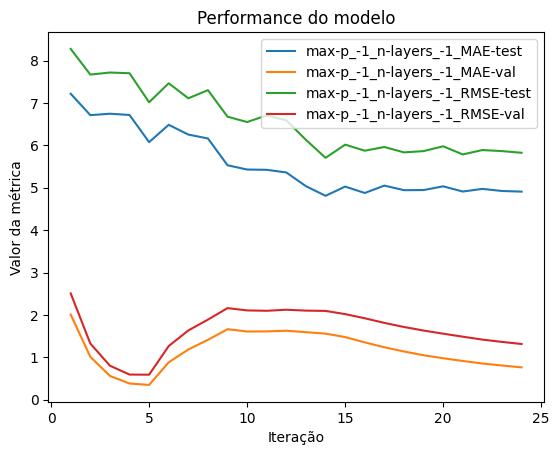

In [52]:
# plt.figure(figsize=(9,6))
plot_errors(folder_to_results_map, val=True, test=True, metrics=['MAE', "RMSE"], target_dirs=["max-p_-1_n-layers_-1"])
plt.title("Performance do modelo")
# plt.legend(loc=(0.6, 0.15))
plt.savefig("all_p_all_l_resources_comp.png")
plt.show()

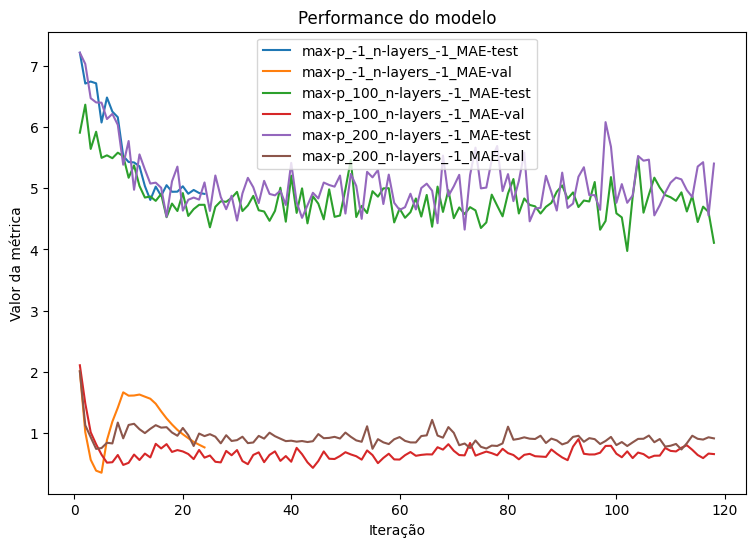

In [53]:
plt.figure(figsize=(9,6))
plot_errors(folder_to_results_map, val=True, test=True, metrics=['MAE'], 
            target_dirs=["max-p_-1_n-layers_-1", "max-p_100_n-layers_-1",
                        "max-p_200_n-layers_-1"])
plt.title("Performance do modelo")
# plt.legend(loc=(0.6, 0.15))
plt.savefig("var_p_all_l.png")
plt.show()

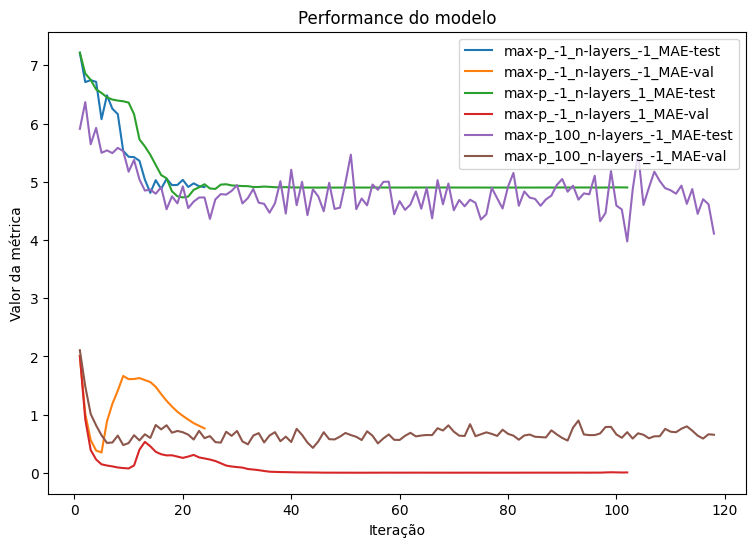

In [54]:
plt.figure(figsize=(9,6))
plot_errors(folder_to_results_map, val=True, test=True, metrics=['MAE'], 
            target_dirs=["max-p_-1_n-layers_-1", "max-p_-1_n-layers_1",
                        "max-p_100_n-layers_-1"])
plt.title("Performance do modelo")
# plt.legend(loc=(0.6, 0.15))
plt.savefig("all_p_1_l.png")
plt.show()

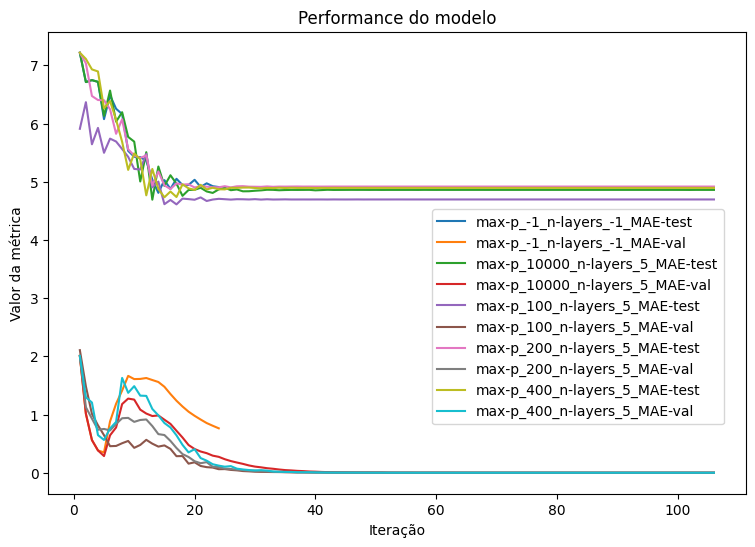

In [55]:
plt.figure(figsize=(9,6))
plot_errors(folder_to_results_map, val=True, test=True, metrics=['MAE'], 
            target_dirs=["max-p_-1_n-layers_-1", "max-p_100_n-layers_5",
                         "max-p_200_n-layers_5", "max-p_400_n-layers_5", 
                         "max-p_10000_n-layers_5"])
plt.title("Performance do modelo")
plt.legend(loc=(0.55, 0.15))
plt.savefig("var_p_5_l.png")
plt.show()

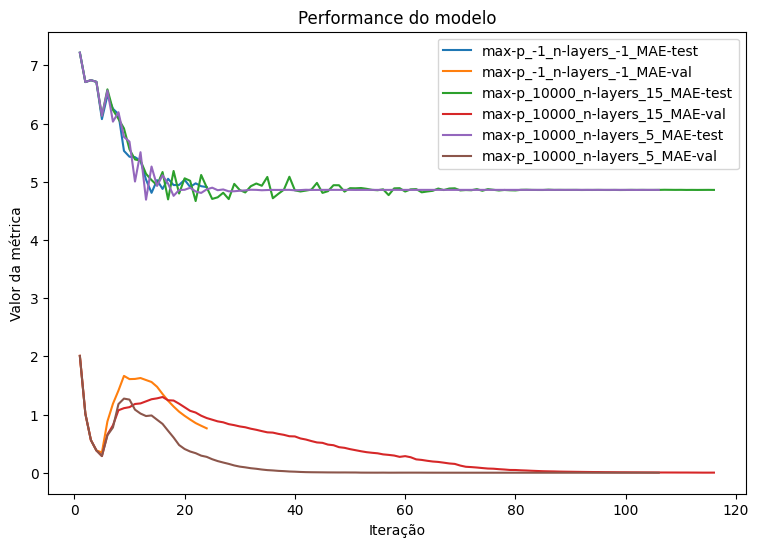

In [56]:
plt.figure(figsize=(9,6))
plot_errors(folder_to_results_map, val=True, test=True, metrics=['MAE'], 
            target_dirs=["max-p_-1_n-layers_-1", "max-p_10000_n-layers_15",
                        "max-p_10000_n-layers_5"])
plt.title("Performance do modelo")
# plt.legend(loc=(0.55, 0.15))
plt.savefig("10000_p_var_l.png")
plt.show()

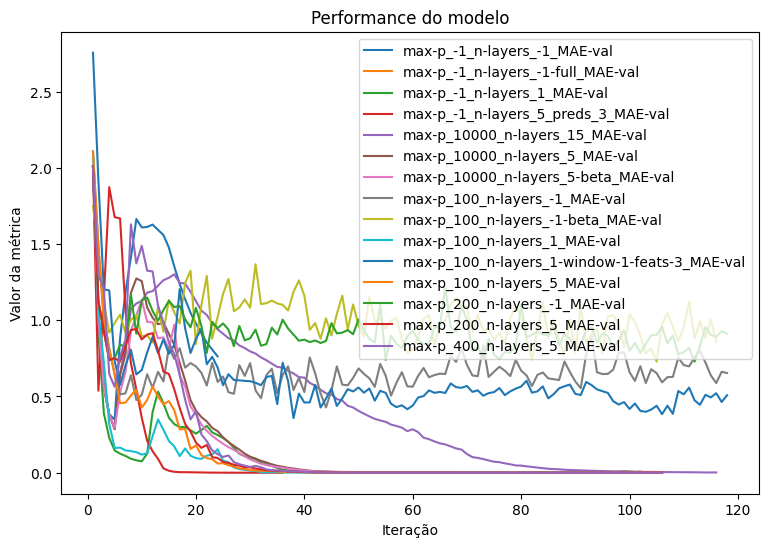

In [57]:
plt.figure(figsize=(9,6))
plot_errors(folder_to_results_map, val=True, test=False, metrics=['MAE'])
plt.title("Performance do modelo")
# plt.legend(loc=(0.6, 0.15))
plt.savefig("model_perf.jpg")
plt.show()

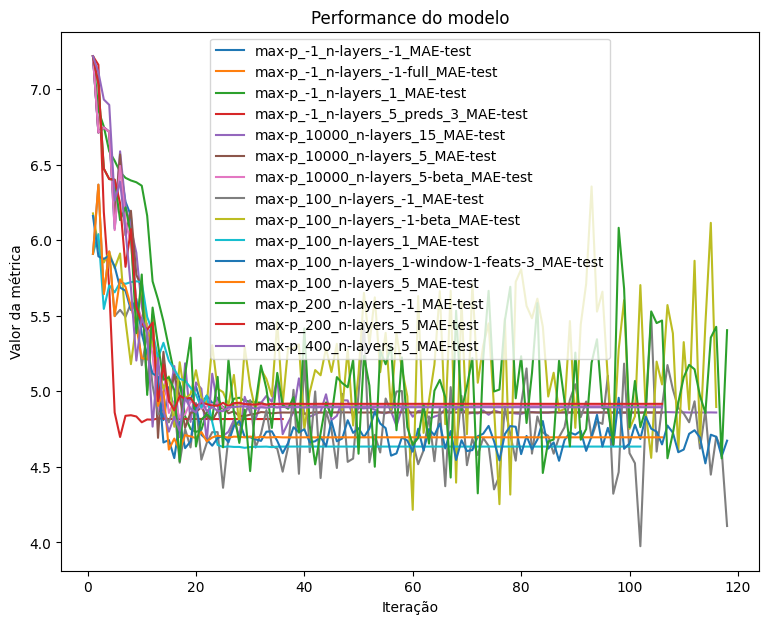

In [68]:
plt.figure(figsize=(9,7))
plot_errors(folder_to_results_map, val=False, test=True, metrics=['MAE'])
plt.title("Performance do modelo")
# plt.legend(loc=(0.6, 0.15))
plt.savefig("model_perf.jpg")
plt.show()

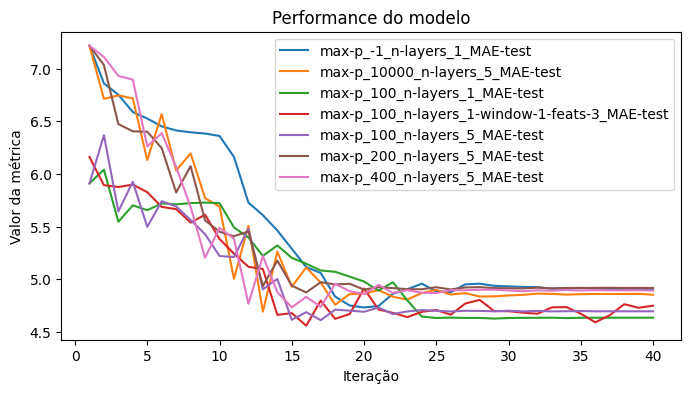

In [59]:
plt.figure(figsize=(8,4))
plot_errors(folder_to_results_map, metrics=['MAE'], test=True,
            target_dirs=["max-p_200_n-layers_5", "max-p_100_n-layers_5", "max-p_400_n-layers_5",
                        "max-p_100_n-layers_1", "max-p_-1_n-layers_1", "max-p_100_n-layers_1-window-1-feats-3",
                        "max-p_10000_n-layers_5"], 
            max_it=40)
plt.title("Performance do modelo")
plt.show()

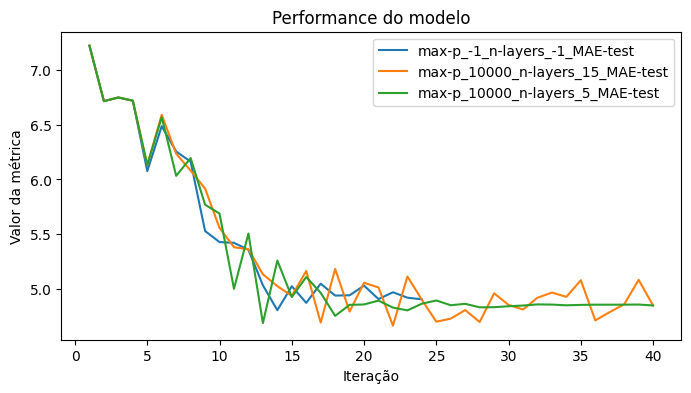

In [60]:
plt.figure(figsize=(8,4))
plot_errors(folder_to_results_map, metrics=['MAE'], test=True,
            target_dirs=["max-p_10000_n-layers_5", "max-p_10000_n-layers_15", "max-p_-1_n-layers_-1"], 
            max_it=40)
plt.title("Performance do modelo")
plt.show()

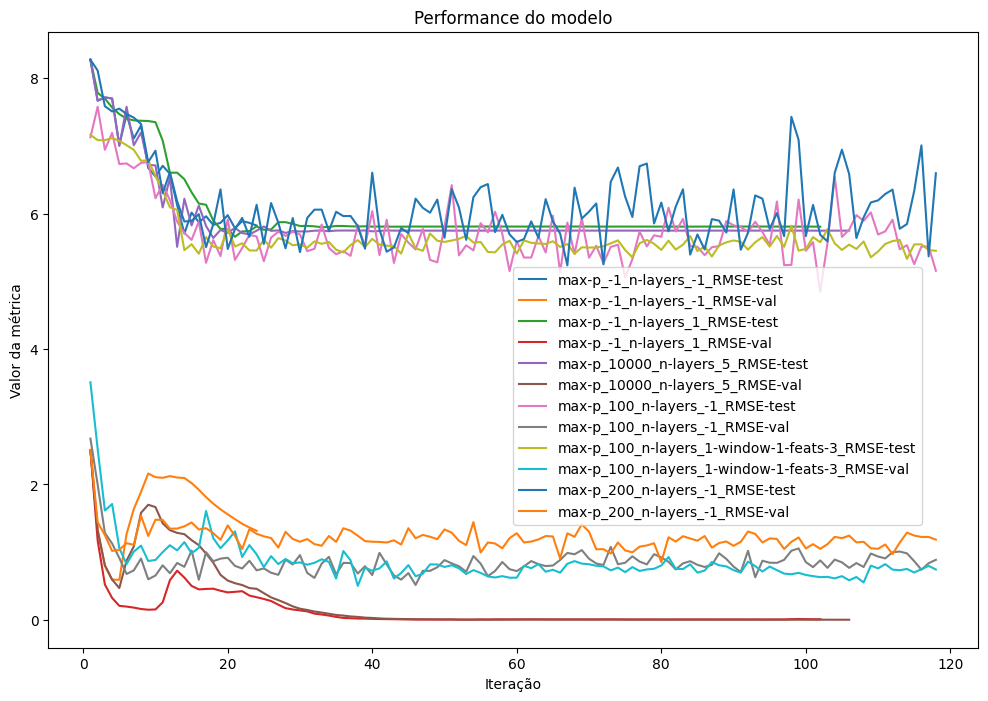

In [63]:
plt.figure(figsize=(12,8))
plot_errors(folder_to_results_map, val=True, metrics=['RMSE'], 
            target_dirs=["max-p_200_n-layers_-1", "max-p_100_n-layers_-1",
                         "max-p_-1_n-layers_-1", "max-p_-1_n-layers_1", 
                        "max-p_100_n-layers_1-window-1-feats-3", "max-p_10000_n-layers_5"], 
            max_it=118)
plt.title("Performance do modelo")
plt.legend(loc=(0.5, 0.2))
plt.savefig("perf1.jpg")
plt.show()

### Definindo Beta dist

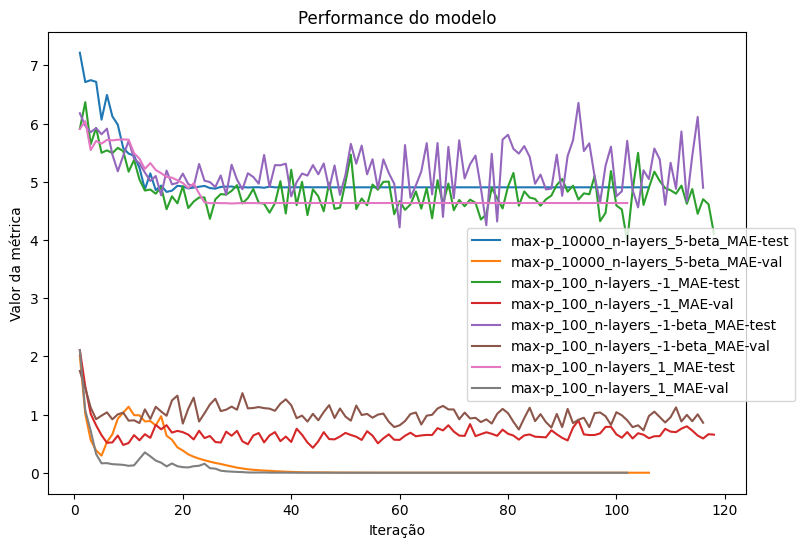

In [64]:
plt.figure(figsize=(9,6))
plot_errors(folder_to_results_map, val=True, test=True, metrics=['MAE'],
            target_dirs=["max-p_100_n-layers_-1-beta", "max-p_100_n-layers_1", 
                         "max-p_100_n-layers_-1", "max-p_10000_n-layers_5-beta"])
plt.title("Performance do modelo")
plt.legend(loc=(0.6, 0.2))
plt.show()

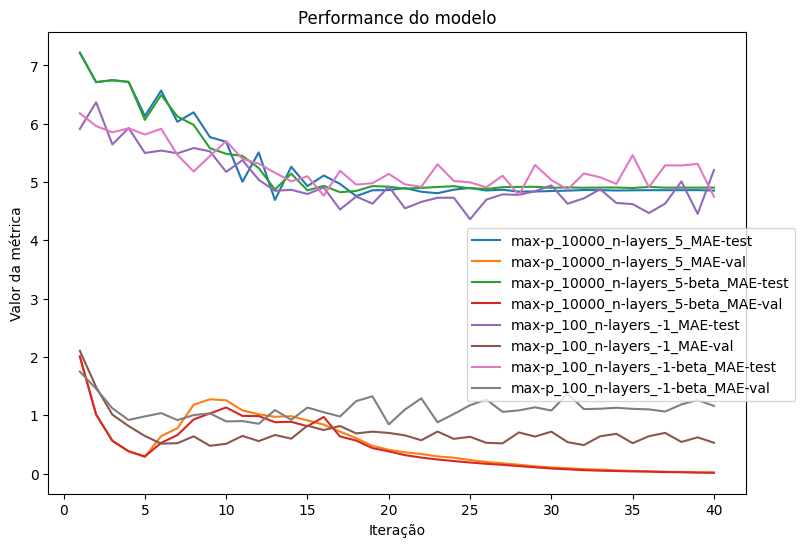

In [67]:
plt.figure(figsize=(9,6))
plot_errors(folder_to_results_map, val=True, test=True, metrics=['MAE'],
            target_dirs=["max-p_100_n-layers_-1-beta", "max-p_10000_n-layers_5", 
                         "max-p_100_n-layers_-1", "max-p_10000_n-layers_5-beta"],
           max_it=40)
plt.title("Performance do modelo")
plt.legend(loc=(0.6, 0.2))
plt.show()

### Definindo camadas a predizer

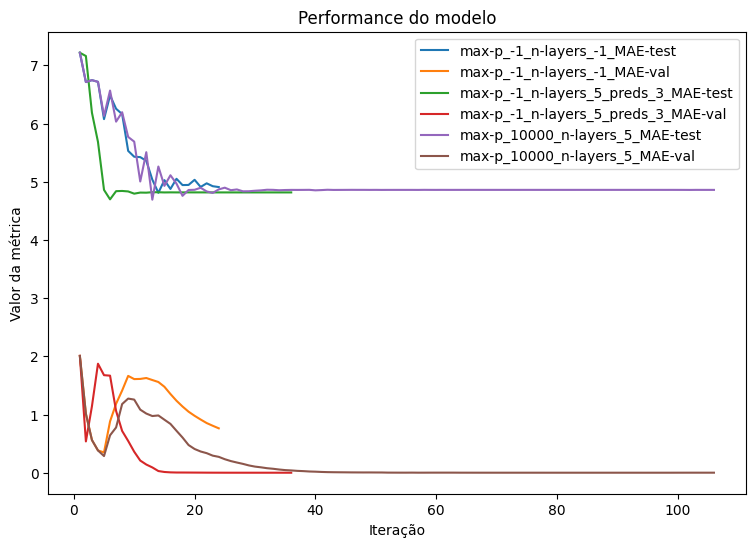

In [14]:
plt.figure(figsize=(9,6))
plot_errors(folder_to_results_map, val=True, test=True, metrics=['MAE'],
            target_dirs=["max-p_-1_n-layers_-1", "max-p_-1_n-layers_5_preds_3",
                        "max-p_10000_n-layers_5"])
plt.title("Performance do modelo")
# plt.legend(loc=(0.6, 0.15))
# plt.savefig("all_p_all_l_resources_comp.png")
plt.show()

### Alterando hiperparâmetros do modelo

#### Alterando min-data

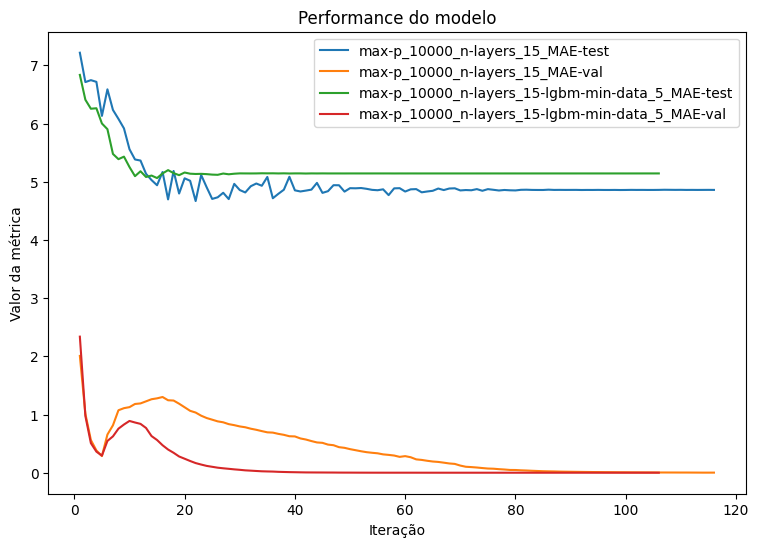

In [17]:
plt.figure(figsize=(9,6))
plot_errors(folder_to_results_map, val=True, test=True, metrics=['MAE'],
            target_dirs=["max-p_10000_n-layers_15", "max-p_10000_n-layers_15",
                        "max-p_10000_n-layers_15-lgbm-min-data_5"])
plt.title("Performance do modelo")
# plt.legend(loc=(0.6, 0.15))
# plt.savefig("all_p_all_l_resources_comp.png")
plt.show()

## Visualizando tempo de execução

In [24]:
def plot_times(dir_to_paths_map, target_dirs:list = None, max_it:int = -1, axs = None):
    if target_dirs is None:
        target_dirs = set(dir_to_paths_map.keys())
        
    for dir in sorted(list(dir_to_paths_map.keys())):
        mapping = dir_to_paths_map[dir]
        if dir in target_dirs:
            times_df = read_times(mapping['times'])
            label = f"{dir}"
            
            its_to_plot = len(times_df) if max_it < 0 else max_it

            target_data = times_df[times_df['iteration'] <= its_to_plot]
            
            if axs is None:
                plt.plot(target_data['iteration'], target_data['seconds']/1000, label=label)
            else:
                axs.plot(target_data['iteration'], target_data['seconds']/1000, label=label)
    
    if axs is None:
        plt.xlabel("Iteração")
        plt.ylabel("Segundos (milhares)")
        # plt.xticks(range(max_it_plotted), range(1, max_it_plotted+1))
        plt.legend()
    else:
        axs.set_xlabel("Iteração")
        axs.set_ylabel("Segundos (milhares)")

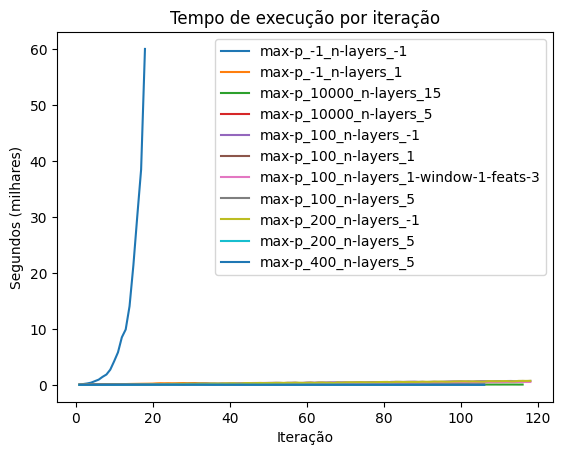

In [25]:
plot_times(folder_to_results_map)
plt.title("Tempo de execução por iteração")
plt.show()

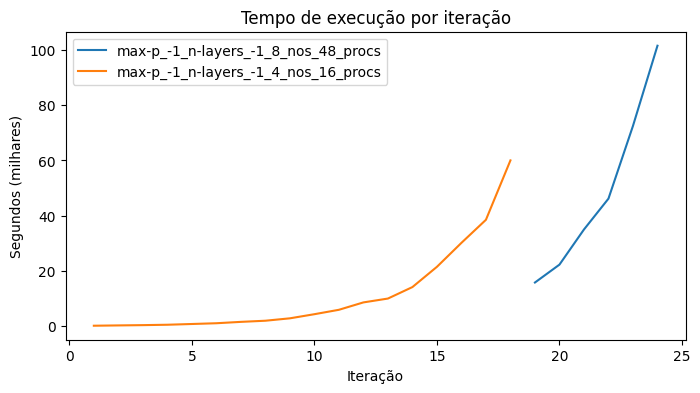

In [26]:
fig = plt.figure(figsize=(8, 4))
times_fast = read_times('./max-p_-1_n-layers_-1'+"/times-8-nos-48-procs.txt")
plt.plot(times_fast['iteration'], times_fast['seconds']/1000, 
         label="max-p_-1_n-layers_-1_8_nos_48_procs", figure=fig)
times_slow = read_times(folder_to_results_map["max-p_-1_n-layers_-1"]["times"])
plt.plot(times_slow['iteration'], times_slow['seconds']/1000, 
         label="max-p_-1_n-layers_-1_4_nos_16_procs", figure=fig)
plt.legend()
plt.ylabel("Segundos (milhares)")
plt.xlabel("Iteração")
plt.title("Tempo de execução por iteração")
plt.savefig("times_comp_resources.png")
plt.show()

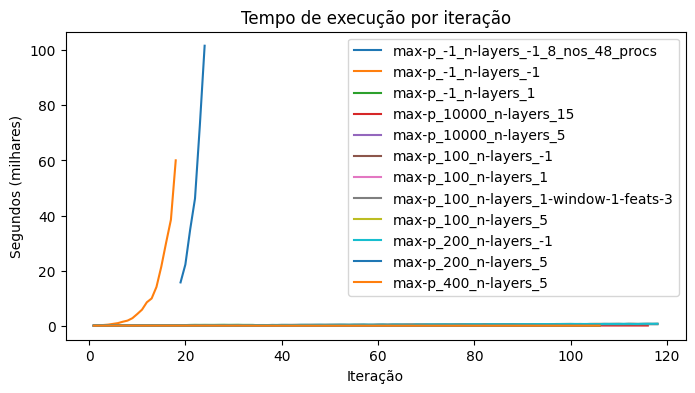

In [27]:
fig = plt.figure(figsize=(8, 4))
times_fast = read_times('./max-p_-1_n-layers_-1'+"/times-8-nos-48-procs.txt")
plt.plot(times_fast['iteration'], times_fast['seconds']/1000, 
         label="max-p_-1_n-layers_-1_8_nos_48_procs", figure=fig)
axes = fig.axes
plot_times(folder_to_results_map, axs=axes[0])
plt.title("Tempo de execução por iteração")
plt.legend()
plt.show()

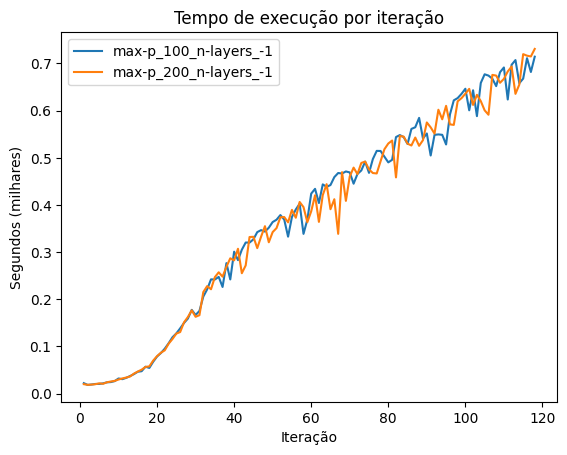

In [28]:
plot_times(folder_to_results_map, target_dirs=["max-p_100_n-layers_-1", "max-p_200_n-layers_-1"])
plt.title("Tempo de execução por iteração")
plt.savefig("var_p_all_l_times.png")
plt.show()

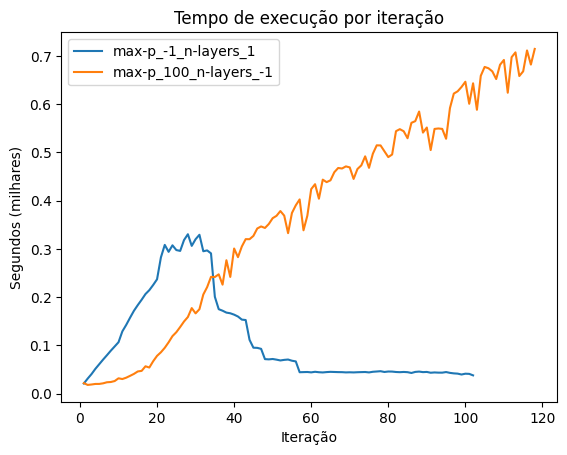

In [29]:
plot_times(folder_to_results_map, target_dirs=["max-p_-1_n-layers_1", "max-p_100_n-layers_-1"])
plt.title("Tempo de execução por iteração")
plt.savefig("all_p_1_l_times.png")
plt.show()

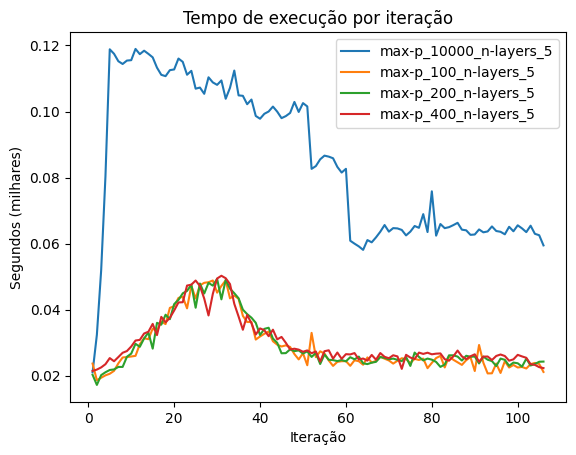

In [30]:
plot_times(folder_to_results_map, 
           target_dirs=[ "max-p_100_n-layers_5",
                         "max-p_200_n-layers_5", "max-p_400_n-layers_5", 
                         "max-p_10000_n-layers_5"])
plt.title("Tempo de execução por iteração")
plt.savefig("var_p_5_l_times.png")
plt.show()

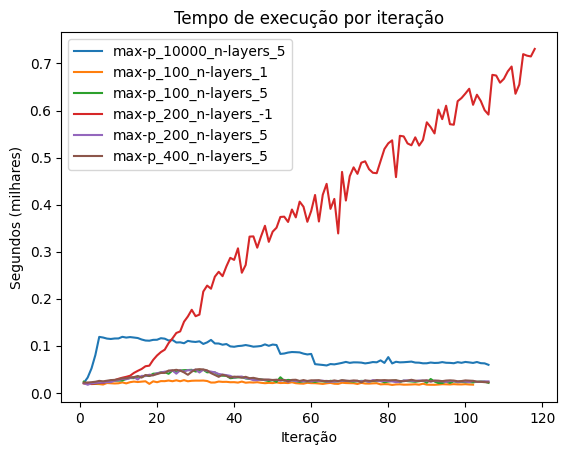

In [31]:
plot_times(folder_to_results_map, target_dirs=["max-p_100_n-layers_5", "max-p_200_n-layers_5",
                                               "max-p_400_n-layers_5", "max-p_200_n-layers_-1",
                                               "max-p_100_n-layers_1", "max-p_10000_n-layers_5"])
plt.title("Tempo de execução por iteração")
plt.show()

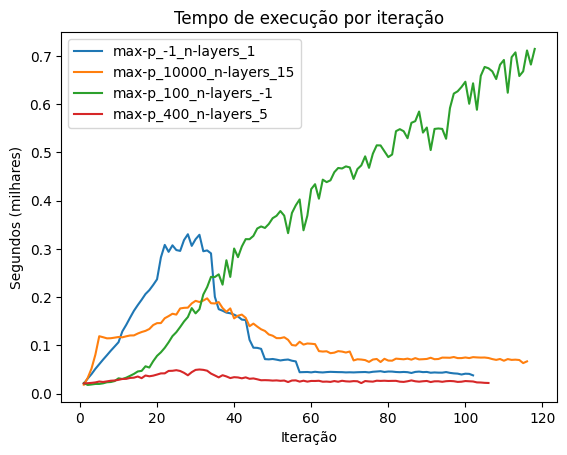

In [32]:
plot_times(folder_to_results_map, target_dirs=["max-p_400_n-layers_5", "max-p_100_n-layers_-1", 
                                               "max-p_-1_n-layers_1", "max-p_10000_n-layers_15"])
plt.title("Tempo de execução por iteração")
plt.show()

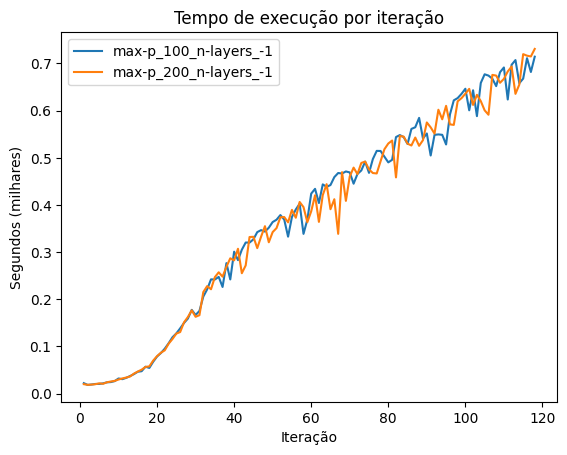

In [33]:
plot_times(folder_to_results_map, target_dirs=["max-p_100_n-layers_-1", "max-p_200_n-layers_-1"])
plt.title("Tempo de execução por iteração")
plt.show()

### Comparando tempo de execução com quantidade de dados de treino

In [34]:
top_left_point = (0, 0)
bottom_right_point = (125, 250)
depth = 32
cube = ExplorationCube(top_left_point, bottom_right_point, depth)

In [35]:
wells_coords = [(34, 97), (98, 46), (55, 30), (101, 132), (33, 184)]

In [36]:
x, y= list(zip(*wells_coords))
wells_coords_df = pd.DataFrame()
wells_coords_df["x"] = x
wells_coords_df["y"] = y
wells_coords_df["Tipo"] = ["Treino", "Treino", "Treino", "Treino", "Teste"]
wells_coords_df["Poço"] = ["7-BUZ-12-RJS", "8-BUZ-21D-RJS", "3-BRSA-1184-RJS",
                          "8-BUZ-32DA-RJS", "7-BUZ-30-RJS"]
wells_coords_df

,x,y,Tipo,Poço
0,34,97,Treino,7-BUZ-12-RJS
1,98,46,Treino,8-BUZ-21D-RJS
2,55,30,Treino,3-BRSA-1184-RJS
3,101,132,Treino,8-BUZ-32DA-RJS
4,33,184,Teste,7-BUZ-30-RJS


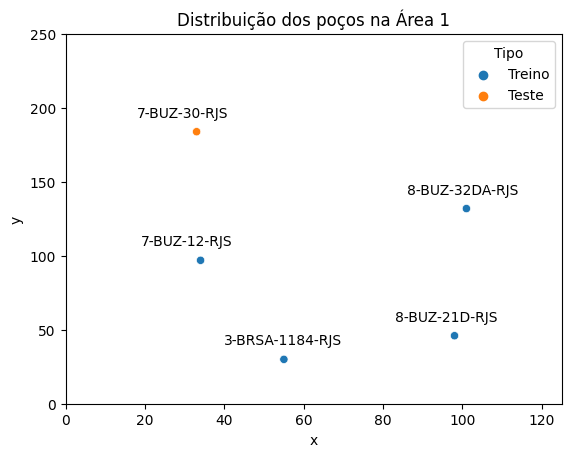

In [37]:
sns.scatterplot(data=wells_coords_df, x="x", y="y", hue="Tipo")
# plt.scatter(x, y)
plt.ylim((0, 250))
plt.xlim((0, 125))
for row in wells_coords_df.iterrows():
    data = row[1]
    plt.text(data['x']-15, data['y']+10, data['Poço'])

plt.title("Distribuição dos poços na Área 1")
plt.xlabel("x")
plt.ylabel("y")
# ax = plt.gca()
# ax.invert_yaxis()
plt.savefig("wells_dist.png")
plt.show()

O último poço é o de teste então vamos tirá-lo da lista

In [38]:
wells_coords = wells_coords[:-1]
wells_coords

[(34, 97), (98, 46), (55, 30), (101, 132)]

In [39]:
for well_coord in wells_coords:
    cube.add_well_at(well_coord[0], well_coord[1])

In [40]:
cube.its_until_point((33, 184))

68

Assim, o poço de teste será atingido na iteração 68

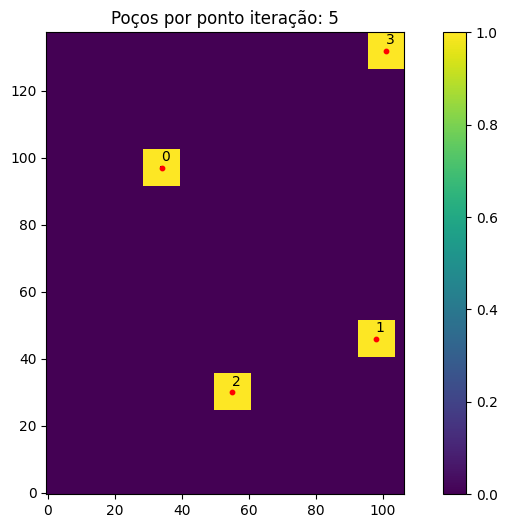

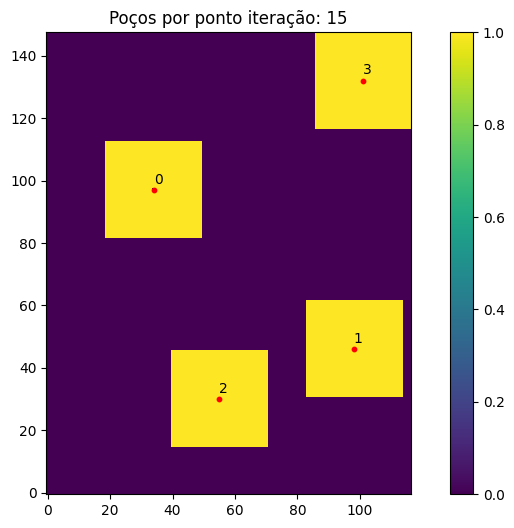

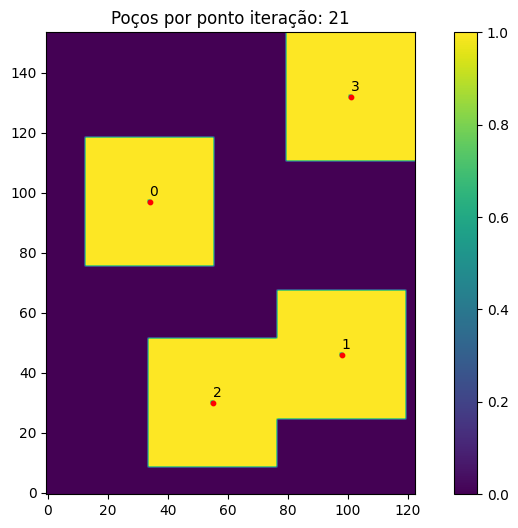

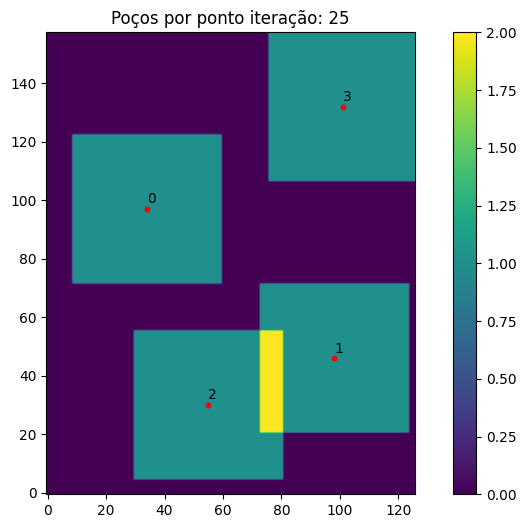

In [41]:
interest_its=[5, 15, 21, 25]
for it in interest_its:
    pred_viz = cube.pred_config_at_it(it).T
    plt.figure(figsize=(10, 6))
    plt.imshow(pred_viz, origin="lower")
    plt.colorbar()
    
    for w_id, w in enumerate(wells_coords):
        plt.text(w[0], w[1]+2, w_id, c='black')
        plt.scatter([w[0]], [w[1]], c='red', s=10)
    
    plt.title(f"Poços por ponto iteração: {it}")
    # plt.tight()
    plt.savefig(f"{it}-config.jpg", bbox_inches='tight')
    plt.show()

In [42]:
num_predicted = list()
total_num_its = 118
print(total_num_its)
for i in range(1, total_num_its+1):
    num_predicted.append(cube.num_predicted_at_it(i))
num_predicted = np.array(num_predicted)    

118


In [43]:
def plot_time_vs_data_size(dir_to_paths_map:dict, data_size:np.ndarray, 
                           target_dirs:list = None, max_it:int = -1, 
                           axs = None):
    max_it_plotted = -1
    if target_dirs is None:
        target_dirs = set(dir_to_paths_map.keys())
        
    for dir in sorted(list(dir_to_paths_map.keys())):
        mapping = dir_to_paths_map[dir]
        if dir in target_dirs:
            times_df = read_times(mapping['times'])
            label = f"{dir}"
            plt.plot(data_size[times_df['iteration']-1]/1000, times_df['seconds']/1000,
                     label=label)
    if axs is None:
        plt.xlabel("Pontos de treino (milhares)")
        plt.ylabel("Segundos (milhares)")
        plt.title("Tempo de execução vs Qt de pontos de treino")
        plt.legend()
        plt.show()
    else:
        axs.set_xlabel("Pontos de treino (milhares)")
        axs.set_ylabel("Segundos (milhares)")

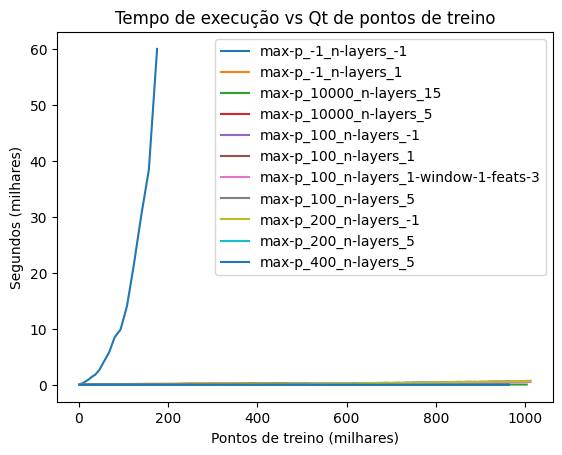

In [44]:
plot_time_vs_data_size(folder_to_results_map, num_predicted)

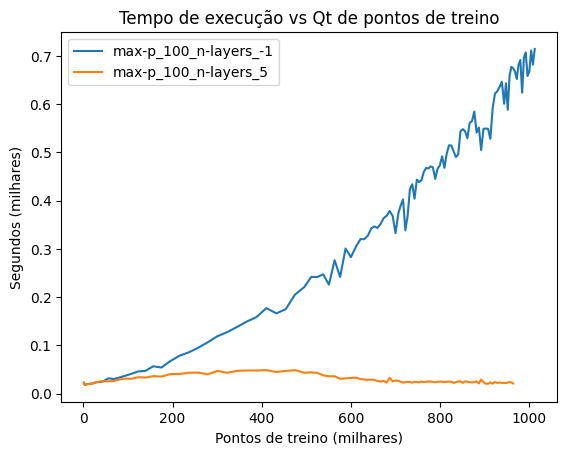

In [45]:
plot_time_vs_data_size(folder_to_results_map, num_predicted, 
                       target_dirs=["max-p_100_n-layers_-1", "max-p_100_n-layers_5"])

## Visualizando as features escolhidas

In [46]:
feat_to_color_map = {
    'curvedness': "green",
    'contur-curvature': "purple",
    'instantaneous-frequency': "lightcoral",
    'most-positive-curvature': "lightgrey",
    'rms-9': "gainsboro",
    'rms-7': "darkgrey",
    'shape-index': "black",
    'gaussian-curvature': "aquamarine",
    'dip-curvature': "olive",
    'max-curvature': "darkturquoise",
    'envelope': "mediumblue",
    'azimuth': "gold",
    'rms-5': "palegreen",
    'min-curvature': "midnightblue",
    'mean-curvature': "red",
    'dip-angle': "orange",
    'most-negative-curvature': "darkgoldenrod", 
    'rms-3': "pink"
}

In [47]:
def get_feats_dict(dir_path, max_it) -> dict:
    df = read_exp_error(dir_path)
    feats_dict = df.query("iteration < @max_it").features.to_dict()
    # print(feats_dict)
    for i in range(len(feats_dict)):
        it_feats = feats_dict[i]
        feats_list = it_feats.split(",")
        feats_list = [feat.strip() for feat in feats_list]
        missing_feats = 10 - len(feats_list)
        if missing_feats > 0:
            feats_list.extend([None]*missing_feats)
        
        feats_dict[i] = feats_list

    return feats_dict

def get_feature_coords(feats_dict) -> dict:
    feats_df = pd.DataFrame.from_dict(feats_dict, orient='index')
    feats_df = feats_df.apply(get_feat_preffix_series)
    feats_df.columns = [f"feat-{i}" for i in range(1, 11)]
    feature_points = dict()

    for row_idx, row in feats_df.iterrows():
        col_idx = 0
        for feature in row:
            if feature is not None:
                feat_points = feature_points.setdefault(feature, [[],[]])
                feat_points[0].append(row_idx+1)
                feat_points[1].append(col_idx+1)
            col_idx +=1

    return feature_points

def get_preffix(feat_name):
    if feat_name is not None:
        # print(feat_name, end=" ")
        splitted = feat_name.split(" ")
        result = splitted[0].split("_")[-3]
        # print(result)
        return result
    return feat_name
    
def get_feat_preffix_series(feature_series):
    serie = feature_series.apply(get_preffix)
    return serie
    
def plot_feats_dict(dirs_mapping, dirs_to_plot:list=None, max_it:int=-1, 
                    figsize:tuple = None, sep_legend:bool=False,
                   max_marker_size:int=62, max_base_it:int=118):
    if dirs_to_plot is None:
        dirs_to_plot = sorted(list(dirs_mapping.keys()))

    dirs_to_plot.sort()
    n_figs = len(dirs_to_plot)

    if figsize is None:
        figsize = (10, 8)
    
    fig, axs = plt.subplots(nrows=n_figs,
                           ncols=1,
                           sharey=True,
                           figsize=figsize,
                           layout="constrained")
    fig.set_figwidth(8)
    last_axs = None
    for dir_id, dir in enumerate(dirs_to_plot):
        if n_figs > 1:
            t_axs = axs[dir_id] 
        else:
            t_axs = axs

        last_axs = t_axs
        
        feats_dict = get_feats_dict(dirs_mapping[dir]['exp-error'], max_it)
        
        feature_points = get_feature_coords(feats_dict)
        marker_size = max_marker_size * (1 - (max_it/max_base_it))
        for feat_name, (it_values, rank_values) in feature_points.items():
            num_points = len(it_values)
            if feat_name in feat_to_color_map:
                t_axs.scatter(it_values, rank_values, marker='s', s=marker_size, label=feat_name,
                             c=feat_to_color_map[feat_name])
            else:
                t_axs.scatter(it_values, rank_values, marker='s', s=marker_size, label=feat_name)
        
        # Define Labels
        t_axs.set_xlabel('Iteração')
        t_axs.set_ylabel('Ordem de escolha')
        
        # t_axs.legend(loc='center left')
        t_axs.axis([None, None, -1, 1])

        n_top_ranked = 10
        t_axs.set_ylim(0.5, 0.5+ n_top_ranked)
        t_axs.set_xlim(0, max_it+(max_it/2.3))
        t_axs.set_yticks([rank for rank in range(1, 11)])
        x_tick_step = 5
        t_axs.set_xticks([1]+[it for it in range(5, max_it+1, x_tick_step)])
        t_axs.grid(axis="x")
        t_axs.set_title(dir)
        if sep_legend:
            t_axs.legend(loc="upper right")

    #voltar
    fig.gca().invert_yaxis()
    if not sep_legend:
        handles, labels = last_axs.get_legend_handles_labels()
        fig.legend(handles, labels, loc=(0.72, 0.3))
    fig.suptitle("Ordem de escolha de features por iteração")
    # fig.tight_layout()

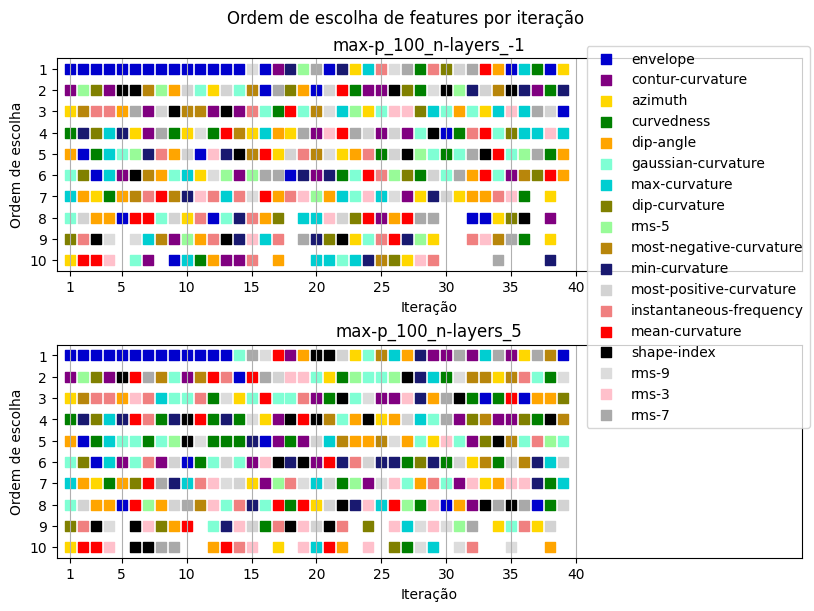

In [48]:
plot_feats_dict(folder_to_results_map, figsize=(8, 6), dirs_to_plot=["max-p_100_n-layers_-1", 
                                                                     "max-p_100_n-layers_5"],
                max_it=40, max_base_it=130)
plt.savefig("feats-choices.png")